In [12]:
import sys

sys.path.append('../')
import pandas as pd
import pyomo.environ as pyo
import tensorflow.keras as keras
from omlt import OffsetScaling, OmltBlock
from omlt.io.keras import load_keras_sequential
from omlt.neuralnet import (
    FullSpaceNNFormulation,
    FullSpaceSmoothNNFormulation,
    NetworkDefinition,
    ReducedSpaceSmoothNNFormulation,
    ReluBigMFormulation,
    ReluComplementarityFormulation,
    ReluPartitionFormulation,
)
from pyomo.opt import SolverFactory

from src.ewenpyomo import ewen_model
from src.neural_network import create_nn, data_scaling
from src.omlt_model import create_model


__OMLT__

In [13]:
# Data loading
df = pd.read_csv('../data/datasetcost_v3.csv')
df.drop('total_cost', axis=1, inplace=True)

# Create 3 datasets for each unit
df1 = df.drop(columns=['Total_Cost2', 'Total_Cost3'])
df2 = df.drop(columns=['Total_Cost1', 'Total_Cost3'])
df3 = df.drop(columns=['Total_Cost1', 'Total_Cost2'])

In [14]:
%load_ext autoreload
%autoreload

def normalization(df, inputs, outputs):
    # Data scaling
    x, y, x_offset, x_factor, \
        y_offset, y_factor, scaled_lb, scaled_ub = data_scaling(df, inputs, outputs)
    
    return x, y, x_offset, x_factor, y_offset, y_factor, scaled_lb, scaled_ub

x1, y1, x_offset1, x_factor1, y_offset1, y_factor1, scaled_lb1, scaled_ub1 = normalization(df1, ['Fir1', 'Fir2', 'Fir3', 'Cir1', 'Cir2', 'Cir3'], ['Total_Cost1'])
x2, y2, x_offset2, x_factor2, y_offset2, y_factor2, scaled_lb2, scaled_ub2 = normalization(df2, ['Fir1', 'Fir2', 'Fir3', 'Cir1', 'Cir2', 'Cir3'], ['Total_Cost2'])
x3, y3, x_offset3, x_factor3, y_offset3, y_factor3, scaled_lb3, scaled_ub3 = normalization(df3, ['Fir1', 'Fir2', 'Fir3', 'Cir1', 'Cir2', 'Cir3'], ['Total_Cost3'])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Epoch 1/1000

2/2 - 1s - loss: 1.4184 - val_loss: 1.9393 - 1s/epoch - 741ms/step
Epoch 2/1000
2/2 - 0s - loss: 1.3734 - val_loss: 1.8920 - 54ms/epoch - 27ms/step
Epoch 3/1000
2/2 - 0s - loss: 1.3323 - val_loss: 1.8467 - 48ms/epoch - 24ms/step
Epoch 4/1000
2/2 - 0s - loss: 1.2901 - val_loss: 1.8035 - 48ms/epoch - 24ms/step
Epoch 5/1000
2/2 - 0s - loss: 1.2525 - val_loss: 1.7623 - 47ms/epoch - 23ms/step
Epoch 6/1000
2/2 - 0s - loss: 1.2155 - val_loss: 1.7233 - 47ms/epoch - 23ms/step
Epoch 7/1000
2/2 - 0s - loss: 1.1823 - val_loss: 1.6863 - 63ms/epoch - 32ms/step
Epoch 8/1000
2/2 - 0s - loss: 1.1517 - val_loss: 1.6512 - 47ms/epoch - 24ms/step
Epoch 9/1000
2/2 - 0s - loss: 1.1207 - val_loss: 1.6185 - 63ms/epoch - 32ms/step
Epoch 10/1000
2/2 - 0s - loss: 1.0923 - val_loss: 1.5879 - 62ms/epoch - 31ms/step
Epoch 11/1000
2/2 - 0s - loss: 1.0665 - val_loss: 1.5594 - 52ms/epoch - 26ms/step
Epoch 12/1000
2/2 - 0s - loss: 1.0416 - val_loss: 1.5331 - 58ms/epoch - 29ms/step
Epoch 13/1000
2/2 - 0s - 

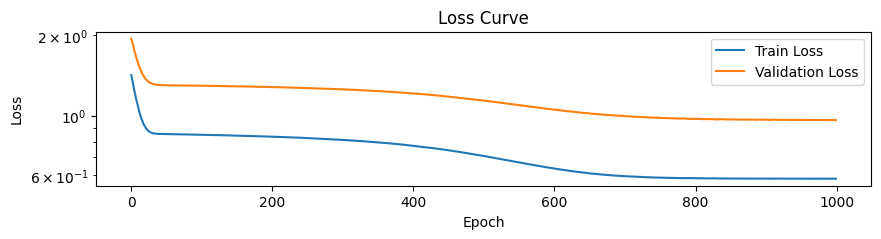

Epoch 1/1000
2/2 - 1s - loss: 1.0233 - val_loss: 0.9930 - 1s/epoch - 659ms/step
Epoch 2/1000
2/2 - 0s - loss: 1.0176 - val_loss: 0.9849 - 78ms/epoch - 39ms/step
Epoch 3/1000
2/2 - 0s - loss: 1.0100 - val_loss: 0.9786 - 62ms/epoch - 31ms/step
Epoch 4/1000
2/2 - 0s - loss: 1.0061 - val_loss: 0.9734 - 78ms/epoch - 39ms/step
Epoch 5/1000
2/2 - 0s - loss: 1.0020 - val_loss: 0.9696 - 81ms/epoch - 41ms/step
Epoch 6/1000
2/2 - 0s - loss: 0.9992 - val_loss: 0.9670 - 68ms/epoch - 34ms/step
Epoch 7/1000
2/2 - 0s - loss: 0.9983 - val_loss: 0.9652 - 65ms/epoch - 32ms/step
Epoch 8/1000
2/2 - 0s - loss: 0.9975 - val_loss: 0.9639 - 88ms/epoch - 44ms/step
Epoch 9/1000
2/2 - 0s - loss: 0.9974 - val_loss: 0.9629 - 77ms/epoch - 38ms/step
Epoch 10/1000
2/2 - 0s - loss: 0.9967 - val_loss: 0.9621 - 86ms/epoch - 43ms/step
Epoch 11/1000
2/2 - 0s - loss: 0.9963 - val_loss: 0.9613 - 90ms/epoch - 45ms/step
Epoch 12/1000
2/2 - 0s - loss: 0.9958 - val_loss: 0.9605 - 66ms/epoch - 33ms/step
Epoch 13/1000
2/2 - 0s - l

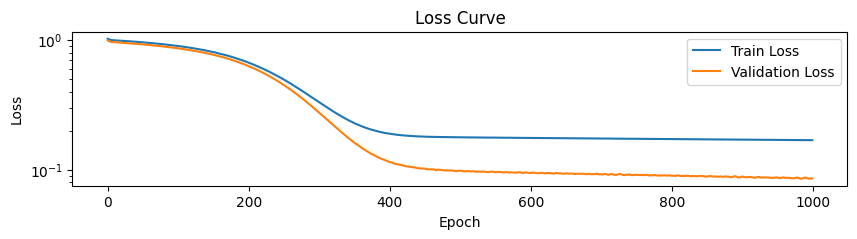

Epoch 1/1000
2/2 - 3s - loss: 2.1225 - val_loss: 1.8229 - 3s/epoch - 1s/step
Epoch 2/1000
2/2 - 0s - loss: 2.0662 - val_loss: 1.7730 - 110ms/epoch - 55ms/step
Epoch 3/1000
2/2 - 0s - loss: 2.0105 - val_loss: 1.7246 - 114ms/epoch - 57ms/step
Epoch 4/1000
2/2 - 0s - loss: 1.9583 - val_loss: 1.6778 - 105ms/epoch - 52ms/step
Epoch 5/1000
2/2 - 0s - loss: 1.9060 - val_loss: 1.6328 - 122ms/epoch - 61ms/step
Epoch 6/1000
2/2 - 0s - loss: 1.8563 - val_loss: 1.5895 - 106ms/epoch - 53ms/step
Epoch 7/1000
2/2 - 0s - loss: 1.8077 - val_loss: 1.5480 - 94ms/epoch - 47ms/step
Epoch 8/1000
2/2 - 0s - loss: 1.7603 - val_loss: 1.5082 - 114ms/epoch - 57ms/step
Epoch 9/1000
2/2 - 0s - loss: 1.7171 - val_loss: 1.4701 - 112ms/epoch - 56ms/step
Epoch 10/1000
2/2 - 0s - loss: 1.6730 - val_loss: 1.4338 - 112ms/epoch - 56ms/step
Epoch 11/1000
2/2 - 0s - loss: 1.6318 - val_loss: 1.3992 - 97ms/epoch - 49ms/step
Epoch 12/1000
2/2 - 0s - loss: 1.5929 - val_loss: 1.3663 - 97ms/epoch - 49ms/step
Epoch 13/1000
2/2 - 0

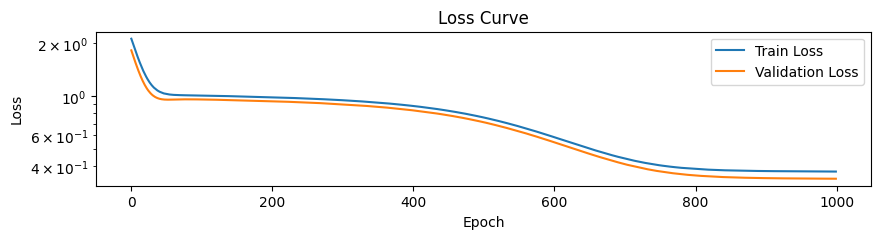

In [15]:
net1 = create_nn(x1, y1, file_name='cost_nn1.keras')
net2 = create_nn(x2, y2, file_name='cost_nn2.keras')
net3 = create_nn(x3, y3, file_name='cost_nn3.keras')

In [16]:
def get_omlt_model(file_name: str, x_offset, x_factor, y_offset, y_factor, scaled_lb, scaled_ub, inputs, outputs):
    omlt_model = pyo.ConcreteModel()
    omlt_model.cost = OmltBlock()
    nn_cost = keras.models.load_model(file_name, compile=False)

    scaler = OffsetScaling(
        offset_inputs={i: x_offset[inputs[i]] for i in range(len(inputs))},
        factor_inputs={i: x_factor[inputs[i]] for i in range(len(inputs))},
        offset_outputs={i: y_offset[outputs[i]] for i in range(len(outputs))},
        factor_outputs={i: y_factor[outputs[i]] for i in range(len(outputs))},
    )

    scaled_input_bounds = {i: (scaled_lb[i], scaled_ub[i]) for i in range(len(inputs))}

    net = load_keras_sequential(
        nn_cost, scaling_object=scaler, scaled_input_bounds=scaled_input_bounds
    )
    omlt_model.cost.build_formulation(FullSpaceSmoothNNFormulation(net))
    return omlt_model

In [17]:
omlt_model1 = get_omlt_model('cost_nn1.keras', x_offset1, x_factor1, y_offset1, y_factor1, scaled_lb1, scaled_ub1, ['Fir1', 'Fir2', 'Fir3', 'Cir1', 'Cir2', 'Cir3'], ['Total_Cost1'])
omlt_model2 = get_omlt_model('cost_nn2.keras', x_offset2, x_factor2, y_offset2, y_factor2, scaled_lb2, scaled_ub2, ['Fir1', 'Fir2', 'Fir3', 'Cir1', 'Cir2', 'Cir3'], ['Total_Cost2'])
omlt_model3 = get_omlt_model('cost_nn3.keras', x_offset3, x_factor3, y_offset3, y_factor3, scaled_lb3, scaled_ub3, ['Fir1', 'Fir2', 'Fir3', 'Cir1', 'Cir2', 'Cir3'], ['Total_Cost3'])

In [20]:
# Load ewen basic model
ewen_pyomo_model = ewen_model()

# Create merged model
model = pyo.ConcreteModel()
model.model_ = ewen_pyomo_model
model.model1 = omlt_model1
model.model2 = omlt_model2
model.model3 = omlt_model3

In [27]:
# Create objective function
model.obj = pyo.Objective(expr=model.model_.EFTotal + \
    0.0001 * model.model1.cost.outputs[0] + \
    0.0001 * model.model2.cost.outputs[0] + \
    0.0001 * model.model3.cost.outputs[0], sense=pyo.minimize)

In [28]:
inputs = ['Fir1', 'Fir2', 'Fir3', 'Cir1', 'Cir2', 'Cir3']

FiR_1 = inputs.index('Fir1')
FiR_2 = inputs.index('Fir2')
FiR_3 = inputs.index('Fir3')
CiR_1 = inputs.index('Cir1')
CiR_2 = inputs.index('Cir2')
CiR_3 = inputs.index('Cir3')

# ANN1
model.constraint1 = pyo.Constraint(expr=model.model_.FiR[1] == model.model1.cost.inputs[FiR_1])
model.constraint2 = pyo.Constraint(expr=model.model_.FiR[2] == model.model1.cost.inputs[FiR_2])
model.constraint3 = pyo.Constraint(expr=model.model_.FiR[3] == model.model1.cost.inputs[FiR_3])

model.constraint4 = pyo.Constraint(expr=model.model_.CiR[1] == model.model1.cost.inputs[CiR_1])
model.constraint5 = pyo.Constraint(expr=model.model_.CiR[2] == model.model1.cost.inputs[CiR_2])
model.constraint6 = pyo.Constraint(expr=model.model_.CiR[3] == model.model1.cost.inputs[CiR_3])

# ANN 2
model.constraint7 = pyo.Constraint(expr=model.model_.FiR[1] == model.model2.cost.inputs[FiR_1])
model.constraint8 = pyo.Constraint(expr=model.model_.FiR[2] == model.model2.cost.inputs[FiR_2])
model.constraint9 = pyo.Constraint(expr=model.model_.FiR[3] == model.model2.cost.inputs[FiR_3])

model.constraint10 = pyo.Constraint(expr=model.model_.CiR[1] == model.model2.cost.inputs[CiR_1])
model.constraint11 = pyo.Constraint(expr=model.model_.CiR[2] == model.model2.cost.inputs[CiR_2])
model.constraint12 = pyo.Constraint(expr=model.model_.CiR[3] == model.model2.cost.inputs[CiR_3])

# ANN 3
model.constraint13 = pyo.Constraint(expr=model.model_.FiR[1] == model.model3.cost.inputs[FiR_1])
model.constraint14 = pyo.Constraint(expr=model.model_.FiR[2] == model.model3.cost.inputs[FiR_2])
model.constraint15 = pyo.Constraint(expr=model.model_.FiR[3] == model.model3.cost.inputs[FiR_3])

model.constraint16 = pyo.Constraint(expr=model.model_.CiR[1] == model.model3.cost.inputs[CiR_1])
model.constraint17 = pyo.Constraint(expr=model.model_.CiR[2] == model.model3.cost.inputs[CiR_2])
model.constraint18 = pyo.Constraint(expr=model.model_.CiR[3] == model.model3.cost.inputs[CiR_3])

In [29]:
solver = pyo.SolverFactory('ipopt')
results = solver.solve(model, tee=False)

In [30]:
print(f'EFTotal value: {model.obj()}')
print(f'Cost_1 value: {model.model1.cost.outputs[0].value}')
print(f'Cost_1 value: {model.model2.cost.outputs[0].value}')
print(f'Cost_1 value: {model.model3.cost.outputs[0].value}')

print(f'ERTotal value: {model.model_.ERTotal()}')
print(f'interc value: {model.model_.interc()}')
print()
print(f'FiR_1 = {model.model_.FiR[1].value}')
print(f'FiR_2 = {model.model_.FiR[2].value}')
print(f'FiR_3 = {model.model_.FiR[3].value}')
print()
print(f'CiR_1 = {model.model_.CiR[1].value}')
print(f'CiR_2 = {model.model_.CiR[2].value}')
print(f'CiR_3 = {model.model_.CiR[3].value}')
print()
print(f'CoR_1 = {model.model_.CoR[1].value}')
print(f'CoR_2 = {model.model_.CoR[2].value}')
print(f'CoR_3 = {model.model_.CoR[3].value}')

EFTotal value: 244.21032748302173
Cost_1 value: 34729.976957628336
Cost_1 value: 145595.78958504598
Cost_1 value: 602268.3581665781
ERTotal value: 220.00000219245405
interc value: 28.0

FiR_1 = 19.952478314821263
FiR_2 = 50.013468860958675
FiR_3 = 150.03405501667413

CiR_1 = 2992.871741523691
CiR_2 = 7502.020294978828
CiR_3 = 14165.26937102354

CoR_1 = 399.0495664477676
CoR_2 = 500.13468868720526
CoR_3 = 1500.3405502443595


__List model constraints__

In [16]:
# Print all constraints of model.model2
for i in model.model2.cost.component_objects(pyo.Constraint, active=True):
    print(f'Constraint: {i}')
    i.pprint()

Constraint: model2.cost._scale_input_constraint
_scale_input_constraint : Size=6, Index=model2.cost.inputs_set, Active=True
    Key : Lower : Body                                                                                          : Upper : Active
      0 :   0.0 :   model2.cost.scaled_inputs[0] - (model2.cost.inputs[0] - 99.0164782439381)/57.17413154295088 :   0.0 :   True
      1 :   0.0 : model2.cost.scaled_inputs[1] - (model2.cost.inputs[1] - 14870.455183543345)/8682.764354206769 :   0.0 :   True
      2 :   0.0 : model2.cost.scaled_inputs[2] - (model2.cost.inputs[2] - 100.4090705170918)/57.539404360536935 :   0.0 :   True
      3 :   0.0 : model2.cost.scaled_inputs[3] - (model2.cost.inputs[3] - 14964.450187900191)/8671.962946884936 :   0.0 :   True
      4 :   0.0 :  model2.cost.scaled_inputs[4] - (model2.cost.inputs[4] - 99.85218703400268)/57.70301524634819 :   0.0 :   True
      5 :   0.0 :  model2.cost.scaled_inputs[5] - (model2.cost.inputs[5] - 14947.51606470589)/8636.744